# # Multi-Level Fusion Hybrid Model for Chest X-Ray Multi-Label Classification
This notebook implements a sophisticated hybrid architecture that combines:
- **ResNet50** with **CBAM attention** at multiple levels
- **Vision Transformer (ViT)** for global context
- **Multi-level feature fusion** at different scales
- **Custom weighted focal loss** for imbalanced classes
- **Progressive training strategy**

In [8]:
# 1. Setup and Imports
import numpy as np
import pandas as pd
import os
import glob
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
from keras.applications import ResNet50
from keras.layers import (Dense, GlobalAveragePooling2D, Input, Reshape, LayerNormalization, 
                         MultiHeadAttention, Dropout, Add, GlobalAveragePooling1D, 
                         BatchNormalization, Conv2D, Multiply, Lambda, Concatenate,
                         MaxPooling2D, AveragePooling2D, Activation, UpSampling2D)
from keras.models import Model
from keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras import backend as K
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import precision_recall_curve, auc, roc_curve, roc_auc_score
import tensorflow_addons as tfa
import warnings
warnings.filterwarnings('ignore')

# Enable mixed precision for GTX 1060 memory savings
tf.keras.mixed_precision.set_global_policy('mixed_float16')

In [2]:
# 2. Data Loading
# Dataset paths
BASE_DIR = "./dataset_balanced/"
CSV_PATH = os.path.join(BASE_DIR, "new_labels.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "new_images", "new_images")
IMAGE_FILES = {os.path.basename(f): f for f in glob.glob(os.path.join(IMAGE_DIR, "*.png"))}

print(f"Total images found: {len(IMAGE_FILES)}")

# Disease labels
labels = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
          'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
          'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

Total images found: 51382


Class Distribution Analysis:
Atelectasis         :  4788 ( 9.32%) - Weight: 0.767
Cardiomegaly        :  4629 ( 9.01%) - Weight: 0.793
Consolidation       :  4481 ( 8.72%) - Weight: 0.819
Edema               :  4554 ( 8.86%) - Weight: 0.806
Effusion            :  5000 ( 9.73%) - Weight: 0.734
Emphysema           :  4467 ( 8.69%) - Weight: 0.822
Fibrosis            :  5039 ( 9.81%) - Weight: 0.728
Hernia              :  5590 (10.88%) - Weight: 0.657
Infiltration        :  5740 (11.17%) - Weight: 0.639
Mass                :  5564 (10.83%) - Weight: 0.660
Nodule              :  5634 (10.96%) - Weight: 0.651
Pleural_Thickening  :  4831 ( 9.40%) - Weight: 0.760
Pneumonia           :  6105 (11.88%) - Weight: 0.601
Pneumothorax        :  4919 ( 9.57%) - Weight: 0.746


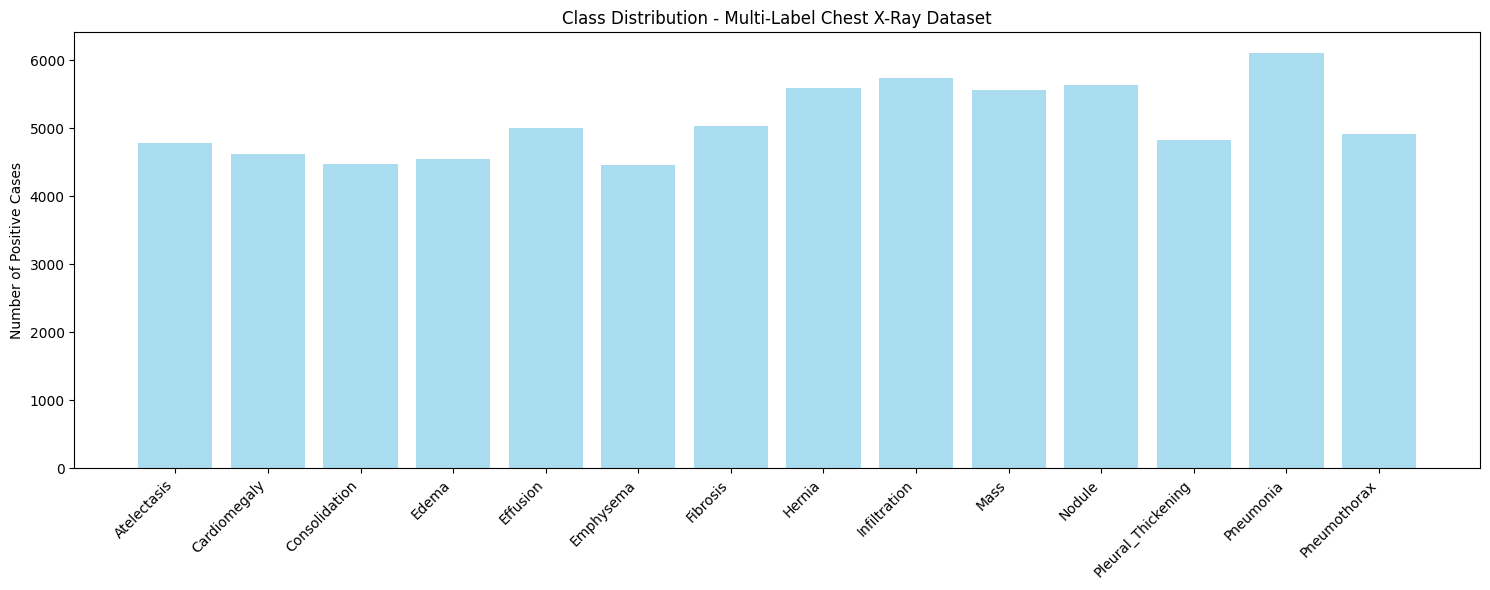

In [3]:
# Load CSV and analyze class distribution
df = pd.read_csv(CSV_PATH)
df = df[['Path'] + labels]

# Analyze class imbalance
class_counts = df[labels].sum()
class_weights = len(df) / (len(labels) * class_counts)  # Inverse frequency weighting

print("Class Distribution Analysis:")
print("="*50)
for label, count, weight in zip(labels, class_counts, class_weights):
    percentage = (count / len(df)) * 100
    print(f"{label:20s}: {count:5d} ({percentage:5.2f}%) - Weight: {weight:.3f}")

# Visualize class distribution
plt.figure(figsize=(15, 6))
plt.bar(range(len(labels)), class_counts, color='skyblue', alpha=0.7)
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.ylabel('Number of Positive Cases')
plt.title('Class Distribution - Multi-Label Chest X-Ray Dataset')
plt.tight_layout()
plt.show()

In [4]:
# Create stratification for train/val split
df['disease_count'] = df[labels].sum(axis=1)
df['has_any_disease'] = (df['disease_count'] > 0).astype(int)

# Stratified split
train_df, val_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42,
    stratify=df['has_any_disease']
)

print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Train positive cases: {train_df['has_any_disease'].sum()}")
print(f"Validation positive cases: {val_df['has_any_disease'].sum()}")

Train samples: 41105
Validation samples: 10277
Train positive cases: 37105
Validation positive cases: 9277


In [5]:
# Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=8,            # Subtle rotations
    width_shift_range=0.08,      # Small shifts
    height_shift_range=0.08,
    horizontal_flip=False,       # Never flip chest X-rays
    zoom_range=0.05,            # Minimal zoom
    brightness_range=[0.9, 1.1], # Slight brightness variation
    fill_mode='nearest',
    shear_range=0.02            # Very subtle shear
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Add image paths
train_df['path'] = train_df['Path'].map(IMAGE_FILES)
val_df['path'] = val_df['Path'].map(IMAGE_FILES)

# Create generators with smaller batch size for GTX 1060
BATCH_SIZE = 4
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=None,
    x_col='path',
    y_col=labels,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=None,
    x_col='path',
    y_col=labels,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

Found 41105 validated image filenames.
Found 10277 validated image filenames.


In [6]:
# 4. Custom Loss Function for Imbalanced Multi-Label Classification

# Fixed Custom Loss Function
class WeightedAsymmetricFocalLoss(tf.keras.losses.Loss):
    """
    Custom loss combining:
    1. Weighted loss for class imbalance
    2. Asymmetric loss for multi-label
    3. Focal loss for hard examples
    """
    
    def __init__(self, class_weights, gamma_pos=1.0, gamma_neg=4.0, 
                 clip=0.05, eps=1e-8, name='weighted_asymmetric_focal_loss'):
        super().__init__(name=name)
        self.class_weights = tf.constant(class_weights, dtype=tf.float32)
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.clip = clip
        self.eps = eps
    
    def call(self, y_true, y_pred):
        # FIXED: Cast y_true to float32 to match y_pred
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        
        # Clip predictions to prevent log(0)
        y_pred = tf.clip_by_value(y_pred, self.eps, 1 - self.eps)
        
        # Asymmetric focusing
        if self.gamma_neg > 0 or self.gamma_pos > 0:
            if self.clip > 0:
                pt = y_pred * y_true + (1 - y_pred) * (1 - y_true)
                pt = tf.clip_by_value(pt, self.clip, 1.0)
            else:
                pt = y_pred * y_true + (1 - y_pred) * (1 - y_true)
            
            # Asymmetric gamma
            gamma = self.gamma_pos * y_true + self.gamma_neg * (1 - y_true)
            focal_weight = tf.pow(1 - pt, gamma)
        else:
            focal_weight = 1.0
        
        # Binary cross entropy
        bce = -(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        
        # Apply focal weight
        focal_loss = focal_weight * bce
        
        # Apply class weights (broadcast across batch dimension)
        weighted_loss = focal_loss * self.class_weights
        
        return tf.reduce_mean(tf.reduce_sum(weighted_loss, axis=1))

# Create custom loss with computed class weights
custom_loss = WeightedAsymmetricFocalLoss(
    class_weights=class_weights.values,
    gamma_pos=0.5,  # Less focusing on easy positives
    gamma_neg=3.0,  # More focusing on hard negatives
    clip=0.05
)
print(f"Class weights range: {class_weights.min():.3f} - {class_weights.max():.3f}")

Class weights range: 0.601 - 0.822


In [7]:
# 5. CBAM Attention Modules

def channel_attention(input_feature, ratio=16, name_prefix=""):
    """Enhanced Channel Attention with different pooling strategies"""
    channel = input_feature.shape[-1]
    
    # Shared MLP layers
    shared_layer_one = Dense(channel // ratio, activation='relu', 
                           name=f'{name_prefix}_ca_dense1')
    shared_layer_two = Dense(channel, name=f'{name_prefix}_ca_dense2')
    
    # Multiple pooling strategies
    avg_pool = GlobalAveragePooling2D(name=f'{name_prefix}_ca_avg_pool')(input_feature)
    max_pool = tf.keras.layers.GlobalMaxPooling2D(name=f'{name_prefix}_ca_max_pool')(input_feature)
    
    avg_pool = Reshape((1, 1, channel))(avg_pool)
    max_pool = Reshape((1, 1, channel))(max_pool)
    
    # Process through shared MLP
    avg_pool = shared_layer_one(avg_pool)
    avg_pool = shared_layer_two(avg_pool)
    
    max_pool = shared_layer_one(max_pool)
    max_pool = shared_layer_two(max_pool)
    
    # Combine and apply sigmoid
    channel_attention_feature = Add(name=f'{name_prefix}_ca_add')([avg_pool, max_pool])
    channel_attention_feature = Activation('sigmoid', name=f'{name_prefix}_ca_sigmoid')(channel_attention_feature)
    
    return Multiply(name=f'{name_prefix}_ca_multiply')([input_feature, channel_attention_feature])

def spatial_attention(input_feature, kernel_size=7, name_prefix=""):
    """Enhanced Spatial Attention"""
    # Channel-wise pooling
    avg_pool = Lambda(lambda x: K.mean(x, axis=3, keepdims=True), 
                     name=f'{name_prefix}_sa_avg_pool')(input_feature)
    max_pool = Lambda(lambda x: K.max(x, axis=3, keepdims=True),
                     name=f'{name_prefix}_sa_max_pool')(input_feature)
    
    # Concatenate
    concat = Concatenate(axis=3, name=f'{name_prefix}_sa_concat')([avg_pool, max_pool])
    
    # Spatial attention convolution
    spatial_attention_feature = Conv2D(filters=1, kernel_size=kernel_size, 
                                     strides=1, padding='same', activation='sigmoid',
                                     name=f'{name_prefix}_sa_conv')(concat)
    
    return Multiply(name=f'{name_prefix}_sa_multiply')([input_feature, spatial_attention_feature])

def cbam_block(input_feature, ratio=16, kernel_size=7, name_prefix="cbam"):
    """Complete CBAM block with proper naming"""
    cbam_feature = channel_attention(input_feature, ratio, f"{name_prefix}_channel")
    cbam_feature = spatial_attention(cbam_feature, kernel_size, f"{name_prefix}_spatial")
    return cbam_feature

In [8]:
# 6. Vision Transformer Components

class PatchEmbedding(tf.keras.layers.Layer):
    """Fixed patch embedding layer with get_config"""
    def __init__(self, patch_size=16, embed_dim=256, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.projection = Conv2D(embed_dim, kernel_size=patch_size, 
                               strides=patch_size, padding='valid')
        
    def call(self, images):
        patches = self.projection(images)
        batch_size = tf.shape(patches)[0]
        h, w = patches.shape[1], patches.shape[2]
        patches = tf.reshape(patches, [batch_size, h * w, self.embed_dim])
        return patches
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "patch_size": self.patch_size,
            "embed_dim": self.embed_dim,
        })
        return config

class MultiHeadSelfAttention(tf.keras.layers.Layer):
    """Memory-efficient multi-head self-attention with get_config"""
    def __init__(self, embed_dim, num_heads=8, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        
        self.qkv = Dense(embed_dim * 3, use_bias=False)
        self.proj = Dense(embed_dim)
        self.dropout = Dropout(0.1)
        
    def call(self, x, training=None):
        batch_size, seq_len, embed_dim = tf.shape(x)[0], tf.shape(x)[1], x.shape[2]
        
        qkv = self.qkv(x)
        qkv = Reshape((seq_len, 3, self.num_heads, self.head_dim))(qkv)
        qkv = tf.transpose(qkv, perm=[2, 0, 3, 1, 4])
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        scale = tf.cast(self.head_dim, dtype=tf.float32) ** -0.5
        attn = tf.matmul(q, k, transpose_b=True) * scale
        attn = tf.nn.softmax(attn, axis=-1)
        attn = self.dropout(attn, training=training)
        
        out = tf.matmul(attn, v)
        out = tf.transpose(out, perm=[0, 2, 1, 3])
        out = Reshape((seq_len, embed_dim))(out)
        out = self.proj(out)
        
        return out
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
        })
        return config

class TransformerBlock(tf.keras.layers.Layer):
    """Fixed transformer block with get_config"""
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        
        self.att = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=dropout_rate
        )
        
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation='gelu'),
            Dropout(dropout_rate),
            Dense(embed_dim)
        ])
        
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(dropout_rate)
        self.dropout2 = Dropout(dropout_rate)
    
    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        
        ffn_output = self.ffn(out1, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)
        
        return out2
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "dropout_rate": self.dropout_rate,
        })
        return config

class PositionalEmbedding(tf.keras.layers.Layer):
    """Learnable positional embedding with get_config"""
    def __init__(self, sequence_length, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.embed_dim = embed_dim
        
    def build(self, input_shape):
        self.position_embeddings = self.add_weight(
            name="position_embeddings",
            shape=(self.sequence_length, self.embed_dim),
            initializer="uniform",
            trainable=True
        )
        super().build(input_shape)
        
    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        pos_emb = tf.expand_dims(self.position_embeddings, 0)
        pos_emb = tf.tile(pos_emb, [batch_size, 1, 1])
        return inputs + pos_emb
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "embed_dim": self.embed_dim,
        })
        return config

In [9]:
# 7. Multi-Level Feature Fusion Architecture

def multi_level_fusion_model(
    input_shape=(224, 224, 3),
    num_classes=14,
    backbone_trainable_layers=20,
    cbam_ratios=[16, 8, 4],
    patch_size=16,
    embed_dim=384,
    num_transformer_blocks=3,
    num_heads=6,
    ff_dim=768,
    transformer_dropout=0.1,
    fusion_levels=['low', 'mid', 'high'],
    fusion_dims=[128, 256, 512],
    final_dim=768
):
    inputs = Input(shape=input_shape, name='input_images')
    
    # =============== CNN BACKBONE (same as before) ===============
    resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    
    for i, layer in enumerate(resnet_base.layers):
        if i < len(resnet_base.layers) - backbone_trainable_layers:
            layer.trainable = False
        else:
            layer.trainable = True
    
    feature_extractor = Model(
        inputs=resnet_base.input,
        outputs=[
            resnet_base.get_layer('conv2_block3_out').output,
            resnet_base.get_layer('conv3_block4_out').output,
            resnet_base.get_layer('conv4_block6_out').output,
            resnet_base.output
        ],
        name='multi_level_feature_extractor'
    )
    
    low_features, mid_features, high_features, top_features = feature_extractor(inputs)
    
    low_cbam = cbam_block(low_features, ratio=cbam_ratios[0], name_prefix="low_level")
    mid_cbam = cbam_block(mid_features, ratio=cbam_ratios[1], name_prefix="mid_level")
    high_cbam = cbam_block(high_features, ratio=cbam_ratios[2], name_prefix="high_level")
    top_cbam = cbam_block(top_features, ratio=8, name_prefix="top_level")
    
    # =============== FIXED VISION TRANSFORMER BRANCH ===============
    
    # Calculate number of patches
    img_height, img_width = input_shape[0], input_shape[1]
    num_patches = (img_height // patch_size) * (img_width // patch_size)
    
    # Patch embedding
    patch_embed = PatchEmbedding(patch_size=patch_size, embed_dim=embed_dim, name='patch_embedding')
    patches = patch_embed(inputs)
    
    # FIXED: Use custom positional embedding that handles batch dimensions
    pos_embed = PositionalEmbedding(num_patches, embed_dim, name='pos_embedding')
    patches = pos_embed(patches)
    patches = Dropout(transformer_dropout, name='patch_dropout')(patches)
    
    # Transformer blocks
    vit_features = patches
    for i in range(num_transformer_blocks):
        vit_features = TransformerBlock(
            embed_dim=embed_dim,
            num_heads=num_heads, 
            ff_dim=ff_dim,
            dropout_rate=transformer_dropout,
            name=f'transformer_block_{i}'
        )(vit_features)
    
    vit_global = GlobalAveragePooling1D(name='vit_global_pool')(vit_features)
    
    # =============== REST OF THE MODEL (same as before) ===============
    
    def adaptive_pool_and_project(features, target_dim, level_name):
        pooled = GlobalAveragePooling2D(name=f'{level_name}_gap')(features)
        projected = Dense(target_dim, activation='relu', name=f'{level_name}_proj')(pooled)
        projected = BatchNormalization(name=f'{level_name}_bn')(projected)
        projected = Dropout(0.2, name=f'{level_name}_dropout')(projected)
        return projected
    
    low_processed = adaptive_pool_and_project(low_cbam, fusion_dims[0], 'low')
    mid_processed = adaptive_pool_and_project(mid_cbam, fusion_dims[1], 'mid') 
    high_processed = adaptive_pool_and_project(high_cbam, fusion_dims[2], 'high')
    top_processed = adaptive_pool_and_project(top_cbam, fusion_dims[2], 'top')
    
    vit_processed = Dense(fusion_dims[2], activation='relu', name='vit_proj')(vit_global)
    vit_processed = BatchNormalization(name='vit_bn')(vit_processed)
    vit_processed = Dropout(0.2, name='vit_dropout')(vit_processed)
    
    # Hierarchical fusion
    level1_concat = Concatenate(name='level1_concat')([low_processed, mid_processed])
    level1_fused = Dense(fusion_dims[1], activation='relu', name='level1_fusion')(level1_concat)
    level1_fused = BatchNormalization(name='level1_bn')(level1_fused)
    
    level2_concat = Concatenate(name='level2_concat')([level1_fused, high_processed])
    level2_fused = Dense(fusion_dims[2], activation='relu', name='level2_fusion')(level2_concat)
    level2_fused = BatchNormalization(name='level2_bn')(level2_fused)
    
    level3_concat = Concatenate(name='level3_concat')([level2_fused, top_processed])
    level3_fused = Dense(fusion_dims[2], activation='relu', name='level3_fusion')(level3_concat)
    level3_fused = BatchNormalization(name='level3_bn')(level3_fused)
    
    final_concat = Concatenate(name='final_concat')([level3_fused, vit_processed])
    final_features = Dense(final_dim, activation='relu', name='final_projection')(final_concat)
    final_features = BatchNormalization(name='final_bn')(final_features)
    final_features = Dropout(0.4, name='final_dropout')(final_features)
    
    # Classification head
    x = final_features
    x = Dense(512, activation='relu', name='cls_dense1')(x)
    x = BatchNormalization(name='cls_bn1')(x)
    x = Dropout(0.3, name='cls_dropout1')(x)
    
    x = Dense(256, activation='relu', name='cls_dense2')(x)
    x = BatchNormalization(name='cls_bn2')(x)
    x = Dropout(0.3, name='cls_dropout2')(x)
    
    outputs = Dense(num_classes, activation='sigmoid', dtype='float32', name='predictions')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='MultiLevel_Fusion_Model')
    return model, resnet_base

In [10]:
# 8. Model Creation

# Create the multi-level fusion model
print("Creating multi-level fusion model...")
model, resnet_backbone = multi_level_fusion_model(
    input_shape=(224, 224, 3),
    num_classes=len(labels),
    backbone_trainable_layers=20,
    cbam_ratios=[16, 8, 8],
    patch_size=16,
    embed_dim=256,  # GTX 1060 optimized
    num_transformer_blocks=2,
    num_heads=4,
    ff_dim=512,
    transformer_dropout=0.2,
    fusion_levels=['low', 'mid', 'high'],
    fusion_dims=[128, 256, 512],
    final_dim=768
)
print(f"📊 Total parameters: {model.count_params():,}")

Creating multi-level fusion model...
📊 Total parameters: 30,499,690


In [11]:
model.summary(line_length=120)

Model: "MultiLevel_Fusion_Model"
________________________________________________________________________________________________________________________
 Layer (type)                          Output Shape               Param #       Connected to                            
 input_images (InputLayer)             [(None, 224, 224, 3)]      0             []                                      
                                                                                                                        
 multi_level_feature_extractor (Functi  [(None, 56, 56, 256),     23587712      ['input_images[0][0]']                  
 onal)                                  (None, 28, 28, 512),                                                            
                                        (None, 14, 14, 1024),                                                           
                                        (None, 7, 7, 2048)]                                                             

In [12]:
# 9. Progressive Training Strategy

def progressive_training_strategy():
    """
    Multi-stage progressive training:
    1. Warm-up: Train fusion layers and classifier only
    2. Fine-tuning: Unfreeze some CNN layers with custom loss
    3. Final: Full fine-tuning with very low learning rate
    """
    
    # ============= STAGE 1: WARM-UP TRAINING =============
    # STAGE 1: Warm-up Training (Frozen Backbone)")
    
    # Freeze all backbone layers
    for layer in resnet_backbone.layers:
        layer.trainable = False
    
    # Compile with standard BCE for warm-up
    model.compile(
        optimizer=Adam(learning_rate=2e-3, beta_1=0.9, beta_2=0.999, epsilon=1e-7),
        loss='binary_crossentropy',
        metrics=[
            'binary_accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    
    # Stage 1 callbacks
    stage1_callbacks = [
        EarlyStopping(monitor='val_auc', patience=5, mode='max', 
                     restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, 
                         min_lr=1e-6, verbose=1)
    ]
    
    # Training fusion layers and classifier...
    history1 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=12,
        callbacks=stage1_callbacks,
        verbose=1
    )

    # ============= STAGE 2: CUSTOM LOSS FINE-TUNING =============
    # STAGE 2: Custom Loss Fine-tuning
        
    # Unfreeze top CNN layers gradually
    trainable_layers = 30
    for layer in resnet_backbone.layers[-trainable_layers:]:
        layer.trainable = True

    print(f"Unfrozen {trainable_layers} top ResNet layers")

    # Compile with custom weighted loss
    model.compile(
        optimizer=Adam(learning_rate=5e-5, beta_1=0.9, beta_2=0.999, epsilon=1e-7),
        loss=custom_loss,
        metrics=[
            'binary_accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    # Stage 2 callbacks
    stage2_callbacks = [
        EarlyStopping(monitor='val_auc', patience=7, mode='max', 
                        restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_auc', factor=0.3, patience=4, 
                            min_lr=1e-7, mode='max', verbose=1),
        ModelCheckpoint('./output/multi_level_fusion_stage2.keras', 
                        save_best_only=True, monitor='val_auc', mode='max', verbose=1)
    ]

    # Fine-tuning with custom weighted asymmetric focal loss...
    history2 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=18,
        callbacks=stage2_callbacks,
        verbose=1
    )
    # ============= STAGE 3: FULL FINE-TUNING =============
    print("\n🔥 STAGE 3: Full Fine-tuning")

    # Unfreeze all layers
    for layer in model.layers:
        layer.trainable = True

    # Very conservative learning rate
    model.compile(
        optimizer=Adam(learning_rate=1e-5, beta_1=0.9, beta_2=0.999, epsilon=1e-7),
        loss=custom_loss,
        metrics=[
            'binary_accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    # Stage 3 callbacks
    stage3_callbacks = [
        EarlyStopping(monitor='val_auc', patience=5, mode='max', 
                    restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, 
                        min_lr=1e-8, mode='max', verbose=1),
        ModelCheckpoint('./output/multi_level_fusion_final.keras', 
                    save_best_only=True, monitor='val_auc', mode='max', verbose=1)
    ]

    print("Full model fine-tuning with ultra-low learning rate...")
    history3 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        callbacks=stage3_callbacks,
        verbose=1
    )

    return history1, history2, history3

In [13]:
progressive_training_strategy()

Epoch 1/12
10277/10277 [==============================] - 1743s 168ms/step - loss: nan - binary_accuracy: 0.8972 - auc: 0.5015 - precision: 0.1245 - recall: 0.0064 - val_loss: nan - val_binary_accuracy: 0.9003 - val_auc: 0.5000 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 0.0020
Epoch 2/12
10277/10277 [==============================] - 1628s 158ms/step - loss: nan - binary_accuracy: 0.9009 - auc: 0.5004 - precision: 0.1538 - recall: 7.0179e-05 - val_loss: nan - val_binary_accuracy: 0.9003 - val_auc: 0.5000 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 0.0020
Epoch 3/12
10277/10277 [==============================] - ETA: 0s - loss: nan - binary_accuracy: 0.9009 - auc: 0.5003 - precision: 0.2273 - recall: 8.7724e-05
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0010000000474974513.
10277/10277 [==============================] - 1829s 178ms/step - loss: nan - binary_accuracy: 0.9009 - auc: 0.5003 - precision: 0.2273 - recall: 8.7724e-05 - val_loss: nan 

(<keras.callbacks.History at 0x21dee6403d0>,
 <keras.callbacks.History at 0x21f91a358d0>)

In [ ]:
# Create output directory
import os
os.makedirs('./output', exist_ok=True)

# Save the final model in multiple formats
print("💾 Saving model...")

# Method 1: Save entire model (.keras format - recommended)
model.save('./output/hybrid_v1.keras')

# Method 2: Save weights only (.h5 format)
model.save_weights('./output/hybrid_v1.h5')

# Method 3: Save in SavedModel format (for deployment)
model.save('./output/saved_model')

print("✅ Model saved successfully!")

ValueError: Unknown layer: PatchEmbedding. Please ensure this object is passed to the `custom_objects` argument. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.